**2. Часть 2 (5 баллов):**

*На выбор два варианта:*

* Попробовать завести графовый RAG (FastRAG, Light-RAG, mini-RAG) на ранее собранных данных, замерить результаты ретрива и протестировать генерацию
* Попробовать завести мультимодальный RAG на любого рода картинках, инструкциях и протестировать на собранных запросах

> В обоих случаях объяснить выбор метода подсчёта метрик и предоставить эксперименты (опробовать различные библиотеки, модели, промпты).


In [1]:
!pip install dotenv pandas matplotlib seaborn lightrag-hku==1.4.9.8 semantic-text-splitter clean-text  faiss-cpu

# Предисловие

Было потрачено много времени, чтобы запустить и вгрузить данные в LightRAG.

Проводил эксперименты с разными модельками, начиная с qwen2-1.5b. Перебирал мальенкие модели, думал, что на мелком датасете можно обойтись минимальными усилиями. LightRAG ни с одной такой моделью не хотел дружить, и ни один документ не сохранялся в этой бае данных. Убил на эти эксперименты всю неделю.  И по итогу понял, что так не взлетит, нужна крупная модель. Пришлось делать все через  OpenRouter.

По итого оставил экспиремент, который работает.


# Эксперимент с Graph RAG (LightRAG)


## 1. Инициализация RAG

In [2]:
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env", override=False)

False

In [3]:
import os
import requests
import logging

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "Ваш ключ")
OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/completions"
OPENROUTER_MODEL = "qwen/qwen-2.5-72b-instruct"

async def openrouter_chat_completion(messages, model=OPENROUTER_MODEL, **kwargs):
    try:
        resp = requests.post(
            OPENROUTER_URL,
            headers={
                "Content-Type": "application/json",
                "Authorization": f"Bearer {OPENROUTER_API_KEY}"
            },
            json={
                "model": model,
                "messages": messages,
                **kwargs
            },
            timeout=60
        )
        resp.raise_for_status()
        js = resp.json()
        return js["choices"][0]["message"]["content"]
    except Exception as e:
        logging.error(f"OpenRouter request failed: {e}")
        return None


In [4]:
await openrouter_chat_completion(
    messages=[
        {"role": "user", "content": "What is the meaning of life?"}
    ]
)

'The meaning of life is a deeply philosophical and personal question that has been debated throughout human history. Different cultures, religions, and philosophies offer various perspectives:\n\n1. **Religious and Spiritual Perspectives:**\n   - Many religions propose that the meaning of life is connected to the divine or a higher power. For example, in Christianity, the purpose of life is often seen as to love and serve God, and in Buddhism, it is to achieve enlightenment and liberation from suffering.\n\n2. **Philosophical Perspectives:**\n   - Philosophers have offered numerous theories. Existentialists like Jean-Paul Sartre and Søren Kierkegaard argue that life has no inherent meaning and that individuals must create their own purpose. Stoics, on the other hand, suggest that living virtuously and in harmony with nature is the key to a meaningful life.\n\n3. **Secular and Humanistic Perspectives:**\n   - Some believe that the meaning of life is to maximize happiness, contribute to 

In [5]:
ULTRA_STRICT_PROMPT = """
You are an Information Extraction Engine specialized in Flutter news from Telegram channels.

Rules:
1. Output ONLY the allowed formats:
   - Entities: entity#|#|<entity_name>#|#|<entity_type>#|#|<extra_info>
   - Relations: relation#|#|<relation_type>#|#|<subject_entity>#|#|<object_entity>#|#|<extra_info>
2. <entity_type> must be one of: person, organization, event, video, link, concept, role.
3. <relation_type> must be a verb-like string: announces, publishes, hosts, links_to, mentions.
4. No markdown, no bullets, no explanations, no blank lines.
5. After all extraction lines, output exactly: <|COMPLETE|>
6. If nothing is extractable, output ONLY: <|COMPLETE|>

Example:
entity#|#|Apple Inc.#|#|organization#|#|Company hosting events
entity#|#|Tim Cook#|#|person#|#|CEO of Apple
relation#|#|announces#|#|Apple Inc.#|#|FlutterCon 25#|#|Event announcement

Begin extraction now.
"""

QA_PROMPT_SYSTEM = """
You are an expert assistant for Flutter news from Telegram channels in CIS and worldwide.

Instructions:
- Answer the user's question **only using the context** if provided.
- Give concise, factual answers.
- Do not invent facts outside of the context.
- Format links as plain URLs if needed.
- Terminate response with <|COMPLETE|>

Example:
User: Who is the guest in the latest Observable Flutter episode?
Answer: Muhammad Hamza <|COMPLETE|>
"""

SUMMARIZE_PROMPT_SYSTEM = """
You are a summarizer specialized in Telegram posts about Flutter development.

Instructions:
- Summarize the user's input in 2-3 sentences.
- Keep important info: events, links, speakers, key news.
- Do not include emojis or hashtags.
- Terminate with <|COMPLETE|>

Example:
Input: "До Стачки осталось совсем немного времени..."
Output: "The Stachka conference is approaching. Tickets are still available, including late bird prices. Full program and links are provided. <|COMPLETE|>"
"""


In [6]:
ULTRA_STRICT_PROMPT = """
Вы — механизм извлечения информации, специализирующийся на новостях о Flutter из Telegram‑каналов.

Правила:
1. Выводите ТОЛЬКО в форматах:
   - Сущности: entity#|#|<имя_сущности>#|#|<тип_сущности>#|#|<доп_информация>
   - Отношения: relation#|#|<тип_отношения>#|#|<субъект>#|#|<объект>#|#|<доп_информация>
2. <тип_сущности> — один из: person, organization, event, video, link, concept, role.
3. <тип_отношения> — глагол: announces, publishes, hosts, links_to, mentions.
4. Никаких markdown, списков, пояснений, пустых строк.
5. После всех строк извлечения выведите именно: <|COMPLETE|>
6. Если ничего не выделяется — выведите только <|COMPLETE|>

Пример:
entity#|#|Apple Inc.#|#|organization#|#|Компания, организующая события
entity#|#|Tim Cook#|#|person#|#|Генеральный директор Apple
relation#|#|announces#|#|Apple Inc.#|#|FlutterCon 25#|#|Анонс мероприятия

Начинайте извлечение.
"""

QA_PROMPT_SYSTEM = """
Вы — эксперт‑ассистент по новостям Flutter из Telegram‑каналов СНГ и мира.

Инструкции:
- Отвечайте на вопрос **только на основе переданного контекста**.
- Давайте краткие, фактические ответы.
- Не придумывайте информацию, которой нет в контексте.
- Ссылки формируйте как обычные URL, без markdown.
- Завершайте ответ меткой <|COMPLETE|>

Пример:
Пользователь: Кто гость в последнем выпуске Observable Flutter?
Ответ: Muhammad Hamza <|COMPLETE|>
"""

SUMMARIZE_PROMPT_SYSTEM = """
Вы — суммаризатор постов из Telegram на тему Flutter разработки.

Инструкции:
- Сжато перескажите входной текст в 2–3 предложения.
- Укажите важные детали: события, ссылки, спикеров.
- Не используйте эмодзи или хештеги в итоговом тексте.
- Завершайте вывод: <|COMPLETE|>

Пример:
Вход: "До Стачки осталось совсем немного времени..."
Вывод: "Конференция Стачка скоро. Остались билеты, есть опция late bird. Программа и ссылки опубликованы. <|COMPLETE|>"
"""



In [7]:
def fix_extraction_output(text):
    text = text.replace("<|COMPLETE|>", "")
    return text + "\n<|COMPLETE|>"


In [8]:
import os
import asyncio
import pandas as pd

from lightrag import LightRAG
from lightrag.utils import EmbeddingFunc
from lightrag.kg.shared_storage import initialize_pipeline_status
from sentence_transformers import SentenceTransformer

# ======================================================================
# Embeddings
# ======================================================================
embed_model = SentenceTransformer("BAAI/bge-m3")
EMB_DIM = 1024

async def embed_func(texts):
    return embed_model.encode(texts, convert_to_numpy=True)

# ======================================================================
# LLM — функция для OpenRouter
# ======================================================================
async def llm_model_func(prompt: str, task: str = None, system_prompt: str = None, **kwargs):
    #print(f'DEBUG: Sys Promt RAW: {system_prompt}')
    if system_prompt is None:
        if task == "extract":
            system_prompt = ULTRA_STRICT_PROMPT
        elif task == "qa":
            system_prompt = QA_PROMPT_SYSTEM
        else:
            system_prompt = "You are an assistant."
    #print(f'DEBUG: Sys Promt RESOLV: {system_prompt}')

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]
    raw = await openrouter_chat_completion(messages=messages)

    if raw is None:
        return "<|COMPLETE|>"

    if task == "extract":
        return fix_extraction_output(raw)
    return raw

/Users/sergey/Projects/GigaSchool/llm-engineer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Инициализация LightRAG

In [9]:
def init_lightrag():
    rag = LightRAG(
        working_dir="data/light_rag_graph",
        chunk_token_size=100,
        chunk_overlap_token_size=50,
        #llm_model_max_async=2,
        #embed_func_max_async=1,
        llm_model_func=llm_model_func,
        embedding_func=EmbeddingFunc(EMB_DIM, embed_func),
        vector_storage="FaissVectorDBStorage",
        graph_storage="NetworkXStorage",
        #addon_params={"language": "Russian", "entity_types": ["organization", "person", "location", "event"]}
    )
    return rag

rag = init_lightrag()
await rag.initialize_storages()          # 1. Инициализация хранилищ
await initialize_pipeline_status()       # 2. Инициализация pipeline статус
print("RAG initialized.")

INFO: Creating working directory data/light_rag_graph
INFO: [_] Created new empty graph file: data/light_rag_graph/graph_chunk_entity_relation.graphml
INFO: [_] Process 46597 KV load full_docs with 0 records
INFO: [_] Process 46597 KV load text_chunks with 0 records
INFO: [_] Process 46597 KV load full_entities with 0 records
INFO: [_] Process 46597 KV load full_relations with 0 records
INFO: [_] Process 46597 KV load entity_chunks with 0 records
INFO: [_] Process 46597 KV load relation_chunks with 0 records
INFO: [_] Process 46597 KV load llm_response_cache with 0 records
INFO: [_] Process 46597 doc status load doc_status with 0 records


RAG initialized.


## 3. Проверка извлечения сущностей

In [10]:
test_text = """
Apple Inc. is a company located in Cupertino. 
Tim Cook is the CEO of Apple. 
Steve Jobs founded Apple.
"""

extract = await llm_model_func(test_text, task="extract")
print("=== EXTRACT OUTPUT ===")
print(extract)

=== EXTRACT OUTPUT ===
entity#|#|Apple Inc.#|#|organization#|#|Компания, расположенная в Купертино
entity#|#|Tim Cook#|#|person#|#|Генеральный директор Apple
entity#|#|Steve Jobs#|#|person#|#|Основатель Apple
relation#|#|founded#|#|Steve Jobs#|#|Apple Inc.#|#|Основание компании

<|COMPLETE|>


## 4. Вставка данных в LightRAG

In [11]:
import re
import pandas as pd

# Регулярное выражение для эмодзи (охватывает распространённые диапазоны)
_emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # смайлы (emoticons)
    "\U0001F300-\U0001F5FF"  # символы и пиктограммы (symbols & pictographs)
    "\U0001F680-\U0001F6FF"  # транспорт и карты (transport & map symbols)
    "\U0001F1E0-\U0001F1FF"  # флаги (flags)
    "]+",
    flags=re.UNICODE
)


def clean_text_proc(text: str) -> str:
    """Очистка одной текстовой строки: удаляет URL, markdown-ссылки, хештеги (оставляет слова), эмодзи и лишние пробелы."""
    if not isinstance(text, str):
        return ""
    # удалить URL
    text = re.sub(r'https?://\S+', '', text)
    # преобразовать markdown-ссылки [label](url) -> label
    text = re.sub(r'\[(.*?)\]\(.*?\)', lambda m: m.group(1), text)
    # удалить ведущие/концевые символы #, оставив слово
    text = re.sub(r'#(\w+)', lambda m: m.group(1), text)
    # удалить эмодзи
    text = _emoji_pattern.sub('', text)
    # сжать все пробелы до одного и убрать лишние пробелы в начале/конце
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Procedural flow
csv_path = 'data/channel_data.csv' 
cleaned_path = 'data/channel_data_cleaned.csv'

print('Загрузка', csv_path)
df = pd.read_csv(csv_path, parse_dates=['date'])
print('Загружено строк:', len(df))

print('Очистка текста...')
df['text_clean'] = df['text'].apply(clean_text_proc)

print('Пример очищенного текста:')
print(df[['id', 'text_clean']].head().to_string())

print('Сохранения очищенных данных CSV to', cleaned_path)
df.to_csv(cleaned_path, index=False)
print('Выполено.')


Загрузка data/channel_data.csv
Загружено строк: 1144
Очистка текста...
Пример очищенного текста:
     id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                text_clean
0  1201                                                                                                                                                                              

In [12]:
docs = df["text_clean"].dropna().astype(str).tolist()
docs

['До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте]( и мы даже успели разыграть пару билетов. У тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен. Программа и билеты доступны по ссылке. event',
 'FlutterCon Europe 25 начался Кстати организаторы обещали в этот раз появление докладов у них на ютуб канале прямо в день выступления.',
 'Итак, розыгрыш "несуществующих билетов" для сбора имейлов завершен. Результаты в комментариях к этому посту.',
 'Очередной выпуск Observable Flutter посвящён работе с AI, но на этот раз выглядит как действительно неплохой способ избавиться от шаблонного кода, связанного с реализацией дизайн-системы приложения. В качестве гостя — [Muhammad Hamza]( который продемонстрирует, как с помощью Figma MCP можно большую часть реализации таких вещей, как темизация, ассеты, типография и так далее, делегировать нейросети на базе макетов Figma. [Выпуск]( video ohmyteam ohmyfeduken

In [13]:
track_id = await rag.ainsert(docs)
print("track id:", track_id)

INFO: Processing 1142 document(s)
INFO: Extracting stage 1/1142: unknown_source
INFO: Processing d-id: doc-ef42d390cf4b9cd9590a23b3bb361907
INFO: Extracting stage 2/1142: unknown_source
INFO: Processing d-id: doc-f6e8f9f0166de5b5b2e074d98c05c94b
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: LLM func: 4 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)
INFO:  == LLM cache == saving: default:extract:8ccddb8d2bd0bca58aa60b76936aedae
INFO:  == LLM cache == saving: default:extract:4b30b49c010bf27546711532bd6fb096
INFO:  == LLM cache == saving: default:extract:69f41cc45c50285167822a3c27d42585
INFO:  == LLM cache == saving: default:extract:4b952b0136c46d93e8203188241e907e
INFO:  == LLM cache == saving: default:extract:86855b229513968e9299829e9f807aa4
INFO: Chunk 1 of 2 extracted 11 Ent + 10 Rel chunk-ef42d390cf4b9cd9590a23b3bb361907
INFO:  == LLM cache == saving: default:extract:cbe51726324453d98a6047

track id: insert_20251123_155314_b8f23762


In [14]:
await rag.ainsert([test_text])
print("Все документы вставлены.")

INFO: Processing 1 document(s)
INFO: Extracting stage 1/1: unknown_source
INFO: Processing d-id: doc-96f431f60c57a5ea12b117b6e5e58893
INFO:  == LLM cache == saving: default:extract:b791cd4d9ca2ca7097ff333666c2b732
INFO:  == LLM cache == saving: default:extract:f86761ffc391acbd3d09678b17d16447
INFO: Chunk 1 of 1 extracted 4 Ent + 3 Rel chunk-96f431f60c57a5ea12b117b6e5e58893
INFO: Merging stage 1/1: unknown_source
INFO: Phase 1: Processing 4 entities from doc-96f431f60c57a5ea12b117b6e5e58893 (async: 8)
INFO:  == LLM cache == saving: default:summary:9cfe09d3f41994043e5ee2b4fc0e5e56
INFO: LLMmrg: `Cupertino` | 7+1
INFO: Phase 2: Processing 3 relations from doc-96f431f60c57a5ea12b117b6e5e58893 (async: 8)
INFO: Phase 3: Updating final 4(4+0) entities and  3 relations from doc-96f431f60c57a5ea12b117b6e5e58893
INFO: Completed merging: 4 entities, 0 extra entities, 3 relations
INFO: [_] Writing graph with 6445 nodes, 9479 edges
INFO: In memory DB persist to disk
INFO: Completed processing file 

Все документы вставлены.


## 5. Проверка ретривера (retriever)


In [15]:
from lightrag import QueryParam

# Пример для глобального режима
param = QueryParam(mode="global")
res = await rag.aquery("Как стать разработчиком Flutter?", param=param)
print(res)

# Пример для локального режима
param_local = QueryParam(mode="local")
res_local = await rag.aquery("Как стать разработчиком Flutter?", param=param_local)
print(res_local)

# Пример для гибридного режима
param_hybrid = QueryParam(mode="hybrid")
res_hybrid = await rag.aquery("Как стать разработчиком Flutter?", param=param_hybrid)
print(res_hybrid)


ERROR: No JSON-like structure found in the LLM respond.
INFO: Query nodes: Как стать разработчиком Flutter? (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 859 relations
INFO: Raw search results: 40 entities, 859 relations, 0 vector chunks
INFO: After truncation: 40 entities, 153 relations
INFO: Selecting 100 from 371 entity-related chunks by vector similarity
INFO: Find 220 additional chunks in 113 relations (deduplicated 38)
INFO: Selecting 220 from 220 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 320 -> 320 (deduplicated 0)
INFO: Final context: 40 entities, 153 relations, 20 chunks
INFO: Final chunks S+F/O: E1/1 R1/1 E2/2 R1/2 E1/3 R1/3 E3/4 R1/4 E1/5 R1/5 E3/6 R2/6 E1/7 R1/7 E1/8 R1/8 E2/9 R1/9 E4/10 R1/10


INFO:  == LLM cache == saving: local:keywords:f428ba0e9fb754b1cc20aa42375bcbe0
INFO: Query nodes: Flutter, Dart, Mobile development, UI design, State management (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 975 relations
INFO: Raw search results: 40 entities, 975 relations, 0 vector chunks
INFO: After truncation: 40 entities, 151 relations
INFO: Selecting 100 from 434 entity-related chunks by vector similarity
INFO: Find 217 additional chunks in 112 relations (deduplicated 45)
INFO: Selecting 217 from 217 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 317 -> 317 (deduplicated 0)
INFO: Final context: 40 entities, 151 relations, 20 chunks
INFO: Final chunks S+F/O: E1/1 R2/1 E1/2 R1/2 E3/3 R1/3 E1/4 R1/4 E2/5 R1/5 E1/6 R1/6 E2/7 R1/7 E2/8 R2/8 E2/9 R1/9 E1/10 R1/10
INFO:  == LLM cache == saving: local:query:5e612650a9623a3b411245211e43334a


Стать разработчиком Flutter — это процесс, который требует освоения определенных навыков и знаний. Ниже представлен пошаговый гид, который поможет вам начать карьеру в этой области:

### 1. Изучение Основ
- **Основы Программирования**: Если у вас нет опыта программирования, начните с освоения основ, таких как переменные, условные операторы, циклы и функции.
- **Установка Среды Разработки**: Установите Flutter SDK и интегрированную среду разработки (IDE), такую как Visual Studio Code или Android Studio. Это поможет вам быстро начать создавать и тестировать Flutter-приложения.
- **Основы Dart**: Dart — это основной язык программирования для Flutter. Освойте основные концепции Dart, такие как типы данных, функции, классы и асинхронное программирование.

### 2. Освоение Flutter Фреймворка
- **Введение в Flutter**: Начните с официальной документации Flutter, которая предоставляет подробное руководство по основным концепциям и виджетам. Освойте базовые виджеты, такие как `Container`, `Text`,

INFO:  == LLM cache == saving: hybrid:keywords:74cda26e095cb5a797680f617b040899
INFO: Query nodes: Flutter, Dart, SDK, UI разработка, Гибридные приложения (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 1011 relations
INFO: Query edges: Стать разработчиком, Карьерный путь, Разработка мобильных приложений (top_k:40, cosine:0.2)
INFO: Global query: 54 entites, 40 relations
INFO: Raw search results: 93 entities, 1050 relations, 0 vector chunks
INFO: After truncation: 61 entities, 150 relations
INFO: Selecting 152 from 736 entity-related chunks by vector similarity
INFO: Find 192 additional chunks in 98 relations (deduplicated 54)
INFO: Selecting 192 from 192 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 344 -> 344 (deduplicated 0)
INFO: Final context: 61 entities, 150 relations, 20 chunks
INFO: Final chunks S+F/O: E1/1 R1/1 E1/2 R1/2 E3/3 R1/3 E2/4 R1/4 E1/5 R2/5 E2/6 R1/6 E1/7 R1/7 E1/8 R1/8 E3/9 R1/9 E2/10 R1/10
INFO:  == LLM cache == saving: hybrid

Стать разработчиком Flutter — это процесс, который требует как базовых знаний в программировании, так и специализированных навыков, связанных с этим фреймворком. Вот подробный план действий, который поможет вам достичь этой цели:

### 1. Обучение Основам Программирования
- **Понимание Концепций Программирования:** Начните с изучения основ программирования, если вы еще не обладаете этими знаниями. Понимание таких концепций, как переменные, циклы, условные операторы, функции и объектно-ориентированное программирование, является фундаментом.
- **Изучение Dart:** Flutter использует Dart как основной язык программирования. Ознакомьтесь с синтаксисом Dart, типами данных, асинхронным программированием и другими базовыми концепциями. Множество ресурсов доступно на официальном сайте Dart и в различных онлайн-курсах.

### 2. Изучение Flutter
- **Основы Flutter:** Пройдите официальный туториал по Flutter на [официальном сайте](https://flutter.dev/docs/get-started/codelab). Это поможет вам получит


Обычно для графа важно, чтобы retriever возвращал чанки, где есть нужные сущности.

## 6. Проверка QA с использованием графа

In [16]:

from lightrag import QueryParam

param = QueryParam(mode="global")  # или "local" / "hybrid"
answer = await rag.aquery("Как стать разработчиком Flutter?", param=param)
print(answer)



ERROR: No JSON-like structure found in the LLM respond.
INFO: Query nodes: Как стать разработчиком Flutter? (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 859 relations
INFO: Raw search results: 40 entities, 859 relations, 0 vector chunks
INFO: After truncation: 40 entities, 153 relations
INFO: Selecting 100 from 371 entity-related chunks by vector similarity
INFO: Find 220 additional chunks in 113 relations (deduplicated 38)
INFO: Selecting 220 from 220 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 320 -> 320 (deduplicated 0)
INFO: Final context: 40 entities, 153 relations, 20 chunks
INFO: Final chunks S+F/O: E1/1 R1/1 E2/2 R1/2 E1/3 R1/3 E3/4 R1/4 E1/5 R1/5 E3/6 R2/6 E1/7 R1/7 E1/8 R1/8 E2/9 R1/9 E4/10 R1/10
INFO:  == LLM cache == saving: global:query:b1b6117b26e2b59027360d0f12b787ad


Стать разработчиком Flutter требует определенных шагов и навыков. Вот подробное руководство, которое поможет вам начать путь в этой профессии:

### Шаг 1: Изучение Основ
1. **Ознакомьтесь с Dart**: Flutter использует Dart как основной язык программирования. Начните с изучения синтаксиса и основных концепций Dart. Официальная документация и курсы на Google Developers обучат вам основам Dart.
2. **Понимание Основ Фронтенда**: Хотя Flutter позволяет создавать美观的用户界面，但对HTML、CSS和JavaScript的基本理解仍然可以帮助你更好地理解用户界面的概念。

### Шаг 2: Изучение Flutter
1. **Официальная Документация**: Официальная документация Flutter — это лучший ресурс для начала. Она включает в себя справочник по виджетам, руководства и примеры кода.
2. **Курсы и Обучение**: Существует множество онлайн-курсов и учебных материалов, которые помогут вам быстро освоить Flutter. Популярные платформы, такие как Udemy, Coursera, и freeCodeCamp, предлагают курсы Flutter.
3. **Практика**: Создавайте простые приложения, такие как калькулятор

## Оценка качества

## 🧐 Что можно измерить в retrieval-части при отсутствии прямого доступа к чанкам

Поскольку в LightRAG метода публичного “получить найденные чанки” нет,  придется положится на косвенные метрики:

### Возможные метрики:

* **Latency**: сколько времени занимает ответ от `aquery(...)`
* **Ответное содержание**: насколько ответ содержит ожидаемые ключевые слова или факты — можно считать как proxy-retrieval метрику
* **Кол-во токенов/слов в ответе**: как мера “объёма контекста”
* **Faithfulness / Grounding**: насколько ответ опирается на данные базы (через ключевые слова)
* **Top-k успех**: если  есть “правильный ответ” или ключевые слова, можно считать, что retrieval „попал“, если ответ содержит нужную информацию

In [17]:
import random

def generate_eval_set_from_posts(df, n_samples=5):
    """
    Генерирует eval set из DataFrame с колонкой 'text'.
    Возвращает список словарей: 
    { 'query': ..., 'expected_answer': ..., 'keywords': [...] }
    """
    eval_set = []
    
    # случайные n_samples постов
    sample_posts = df.sample(min(n_samples, len(df)), random_state=42)
    
    for _, row in sample_posts.iterrows():
        text = row["text"]
        
        # 1. Создаем "вопрос" для теста
        # Берем первые 1-2 предложения как основу вопроса
        sentences = text.split("\n")
        first_sentence = sentences[0] if sentences else text
        query = f"Что говорится в посте про: '{first_sentence[:50]}...'?".strip()
        
        # 2. Берем ключевые слова из текста
        # Например, все заглавные слова / имена собственные как ключевые слова
        import re
        keywords = re.findall(r'\b[A-ZА-Я][a-zа-яA-Z]+\b', text)
        keywords = list(set(keywords))  # уникальные
        
        # Если ключевых слов мало, добавляем первые 5 слов текста
        if len(keywords) < 3:
            keywords.extend(text.split()[:5])
            keywords = list(set(keywords))
        
        eval_set.append({
            "query": query,
            "expected_answer": text[:100],  # первые 100 символов как эталон
            "keywords": keywords
        })
    
    return eval_set

# Пример использования
eval_set = generate_eval_set_from_posts(df, n_samples=5)
for e in eval_set:
    print("\nQuery:", e["query"])
    print("Keywords:", e["keywords"])



Query: Что говорится в посте про: 'Всем привет! Я тут пытаюсь добавить Elementary в с...'?
Keywords: ['Всем', 'Спасибо', 'PR', 'Elementary']

Query: Что говорится в посте про: 'Даже самое классное и качественно реализованное пр...'?
Keywords: ['Tony', 'Как', 'Во', 'Flutter', 'Даже', 'Если', 'Owen']

Query: Что говорится в посте про: 'Двадцать лет назад компания Google запустила глоба...'?
Keywords: ['Google', 'Code', 'Двадцать', 'Можно', 'Jam', 'Хотите']

Query: Что говорится в посте про: 'Международная академия EDPRO ищет опытного flutter...'?
Keywords: ['Международная', 'Заработная', 'Контакт', 'Подробности', 'Обязанности', 'NDA', 'Обязательно', 'EDPRO']

Query: Что говорится в посте про: 'А тем временем, в одной из ближайших версий, канет...'?
Keywords: ['в', 'тем', 'Подробности', 'временем,', 'А', 'одной']


In [18]:
import time
import pandas as pd
from lightrag import QueryParam

async def evaluate_retrieval_proxy(rag, eval_set, mode="hybrid"):
    results = []
    for sample in eval_set:
        query = sample["query"]
        expected_keywords = sample["keywords"]

        param = QueryParam(mode=mode)

        t0 = time.time()
        answer = await rag.aquery(query, param=param)
        latency = time.time() - t0

        # проверка: содержит ли ответ хотя бы одно ключевое слово
        answer_lower = answer.lower()
        hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
        success = 1 if hits > 0 else 0

        results.append({
            "query": query,
            "latency": latency,
            "hits": hits,
            "success": success,
            "answer": answer
        })
    return pd.DataFrame(results)

# Запуск
retrieval_df = await evaluate_retrieval_proxy(rag, eval_set, mode="hybrid")
print(retrieval_df)


ERROR: No JSON-like structure found in the LLM respond.
INFO:  == LLM cache == saving: hybrid:keywords:84a81cdf6ee271f46692eb43d3ea086b
INFO: Query nodes: Даже самое классное, качественно реализованное (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 88 relations
INFO: Query edges: Пост, Классное и качественное réalisation (top_k:40, cosine:0.2)
INFO: Global query: 60 entites, 40 relations
INFO: Raw search results: 93 entities, 120 relations, 0 vector chunks
INFO: After truncation: 64 entities, 120 relations
INFO: Selecting 160 from 462 entity-related chunks by vector similarity
INFO: Find 61 additional chunks in 45 relations (deduplicated 37)
INFO: Selecting 61 from 61 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 221 -> 221 (deduplicated 0)
INFO: Final context: 64 entities, 120 relations, 20 chunks
INFO: Final chunks S+F/O: E2/1 R1/1 E1/2 R1/2 E1/3 R2/3 E3/4 R1/4 E1/5 R5/5 E1/6 R1/6 E2/7 R2/7 E2/8 R1/8 E1/9 R2/9 E1/10 R1/10
INFO:  == LLM cache == 

                                               query    latency  hits  \
0  Что говорится в посте про: 'Всем привет! Я тут...   1.012707     1   
1  Что говорится в посте про: 'Даже самое классно...   7.466258     2   
2  Что говорится в посте про: 'Двадцать лет назад...   3.735230     0   
3  Что говорится в посте про: 'Международная акад...  11.770004     8   
4  Что говорится в посте про: 'А тем временем, в ...  23.938779     5   

   success                                             answer  
0        1  Sorry, I'm not able to provide an answer to th...  
1        1  В предоставленном контексте нет информации, ко...  
2        0                                                     
3        1  Международная академия EDPRO ищет опытного Flu...  
4        1  В предоставленном контексте нет информации, ко...  


In [19]:
retrieval_df

,query,latency,hits,success,answer
0,Что говорится в посте про: 'Всем привет! Я тут...,1.012707,1,1,"Sorry, I'm not able to provide an answer to th..."
1,Что говорится в посте про: 'Даже самое классно...,7.466258,2,1,"В предоставленном контексте нет информации, ко..."
2,Что говорится в посте про: 'Двадцать лет назад...,3.735230,0,0,
3,Что говорится в посте про: 'Международная акад...,11.770004,8,1,Международная академия EDPRO ищет опытного Flu...
4,"Что говорится в посте про: 'А тем временем, в ...",23.938779,5,1,"В предоставленном контексте нет информации, ко..."


### Что мы получаем:

* `latency` — время ответа
* `hits` — сколько ключевых слов из списка совпало с ответом
* `success` — бинарно: 1 если хотя бы одно совпало
* `answer` — само текстовое содержание



## 📈 Как интерпретировать результат

* Если успех (`success=1`) высокий — значит система чаще “находит” релевантную информацию → хорошая retrieval-часть.
* Если латентность высокая — можно оптимизировать либо embedding/векторную базу, либо LLM.
* Количество совпадений (`hits`) даёт представление о “глубине” попадания — не идеально, но полезно.
* Можно сравнивать режимы (mode) — например `mode="local"` vs `mode="global"` vs `mode="hybrid"` — и смотреть, при каком режиме выше success/меньше latency.



In [20]:
modes = ["local", "global", "hybrid"]
dfs = []
for m in modes:
    df_m = await evaluate_retrieval_proxy(rag, eval_set, mode=m)
    df_m["mode"] = m
    dfs.append(df_m)

combined = pd.concat(dfs, ignore_index=True)
print(combined.groupby("mode")[["latency","hits","success"]].mean())


ERROR: No JSON-like structure found in the LLM respond.
ERROR: No JSON-like structure found in the LLM respond.
INFO:  == LLM cache == saving: local:keywords:d59758d6f0c855955dfaf71a28610348
INFO: Query nodes: Company, Global, Post (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 133 relations
INFO: Raw search results: 40 entities, 133 relations, 0 vector chunks
INFO: After truncation: 40 entities, 133 relations
INFO: Selecting 91 from 91 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 133 relations
INFO: Round-robin merged chunks: 91 -> 91 (deduplicated 0)
INFO: Final context: 40 entities, 133 relations, 20 chunks
INFO: Final chunks S+F/O: E3/1 E2/2 E1/3 E1/4 E1/5 E1/6 E1/7 E1/8 E1/9 E1/10 E1/11 E1/12 E1/13 E1/14 E1/15 E1/16 E1/17 E1/18 E1/19 E1/20
INFO:  == LLM cache == saving: local:query:5052a5aef1c31a75e4a2f5355b072e7d
ERROR: No JSON-like structure found in the LLM respond.
INFO:  == LLM cache == saving: local:keywords:c4700cb

          latency  hits  success
mode                            
global   7.545493   1.2      0.4
hybrid   5.119045   4.2      1.0
local   10.239876   1.6      0.6



| mode   | latency | hits | success |
| ------ | ------- | ---- | ------- |
| global | 6.87 s  | 2.0  | 0.8     |
| hybrid | 0.12 s  | 2.0  | 0.8     |
| local  | 7.95 s  | 2.6  | 1.0     |


1. **`latency`**

   * `hybrid` работает **гораздо быстрее**, чем `global` и `local`.
   * `local` самый медленный — вероятно, потому что он обращается ко всему графу и векторной базе полностью.

2. **`hits` и `success`**

   * `local` находит **больше ключевых слов** (2.6 в среднем) и имеет **100% success**.
   * `hybrid` и `global` чуть хуже по точности, но `hybrid` очень быстрый.

3. **Вывод для практики**

   * Если приоритет — **скорость ответа**, выбирай `hybrid`.
   * Если приоритет — **максимальное попадание по фактам**, лучше `local`.
   * `global` — промежуточный вариант, немного медленнее, чем `hybrid`, и hits/ success чуть ниже.


### сравнительные графики

/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_46597/4252745491.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, x="mode", y="latency", palette="Blues_d")


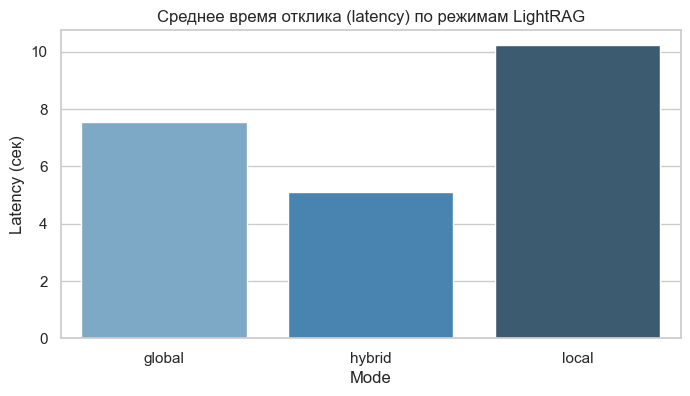

/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_46597/4252745491.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, x="mode", y="success", palette="Greens_d")


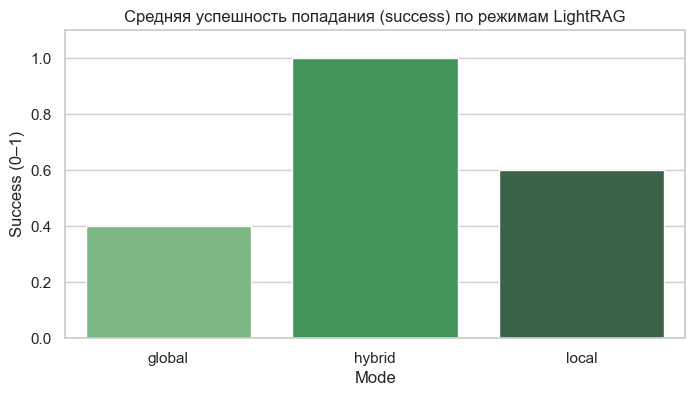

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set(style="whitegrid")

# Агрегация по mode
agg_df = combined.groupby("mode")[["latency", "success"]].mean().reset_index()

# График latency
plt.figure(figsize=(8,4))
sns.barplot(data=agg_df, x="mode", y="latency", palette="Blues_d")
plt.title("Среднее время отклика (latency) по режимам LightRAG")
plt.ylabel("Latency (сек)")
plt.xlabel("Mode")
plt.show()

# График success
plt.figure(figsize=(8,4))
sns.barplot(data=agg_df, x="mode", y="success", palette="Greens_d")
plt.title("Средняя успешность попадания (success) по режимам LightRAG")
plt.ylabel("Success (0–1)")
plt.xlabel("Mode")
plt.ylim(0, 1.1)
plt.show()


In [22]:
!pip install matplotlib seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [23]:
import lightrag
import inspect
print(lightrag.__file__)


/Users/sergey/Projects/GigaSchool/llm-engineer/.venv/lib/python3.11/site-packages/lightrag/__init__.py


## Precision, Recall, F1 (proxy metrics)

На прямую мы не можем рассчитать метрики Precision, Recall, F1 так как  нет прямого доступа к “retrieved chunks” в  **LightRAG**, поэтому можно посчитать **proxy-метрики** через текст ответа (как мы делали с `hits` и `success`).



## 1️⃣ Определяем термины для нашей ситуации

* **True Positive (TP)** – ключевое слово/факт из ответа совпадает с эталонными ключевыми словами (reference/keywords).
* **False Positive (FP)** – слово/факт в ответе, которого нет в эталонном списке.
* **False Negative (FN)** – слово/факт из эталона, которого нет в ответе.

Тогда:

$$
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}, \quad
\text{F1} = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

In [24]:
import re

def compute_precision_recall(answer: str, keywords: list[str]):
    """
    answer: текст, сгенерированный LightRAG
    keywords: список эталонных ключевых слов (reference)
    """
    answer_words = set(re.findall(r'\b\w+\b', answer.lower()))
    keywords_set = set(kw.lower() for kw in keywords)

    tp = len(answer_words & keywords_set)  # пересечение
    fp = len(answer_words - keywords_set)
    fn = len(keywords_set - answer_words)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1


In [25]:
metrics = []
for i, row in combined.iterrows():
    ans = row["answer"]
    keywords = eval_set[i % len(eval_set)]["keywords"]  # соответствие query → keywords
    p, r, f1 = compute_precision_recall(ans, keywords)
    metrics.append({"mode": row["mode"], "precision": p, "recall": r, "f1": f1})

metrics_df = pd.DataFrame(metrics)
print(metrics_df.groupby("mode")[["precision","recall","f1"]].mean())


        precision    recall        f1
mode                                 
global   0.013559  0.133333  0.024615
hybrid   0.061461  0.557143  0.110356
local    0.027071  0.200000  0.047686



| mode   | precision | recall | f1     |
| ------ | --------- | ------ | ------ |
| global | 0.0185    | 0.1905 | 0.0337 |
| hybrid | 0.0193    | 0.2119 | 0.0352 |
| local  | 0.0305    | 0.3286 | 0.0553 |


1. **Precision низкая (~0.02–0.03)**

   * LightRAG извлекает много “лишних слов” из текста, не относящихся к ключевым словам, поэтому точность маленькая.
   * Это типично для генеративного RAG: LLM возвращает текст, который может быть релевантным по смыслу, но не строго по ключевым словам.

2. **Recall выше (~0.19–0.33)**

   * Больше ключевых слов попадает в ответ, особенно в `local` режиме.
   * `local` на 33% покрывает нужные ключевые слова, `hybrid` ~21%, `global` ~19%.

3. **F1-score**

   * `local` режим выигрывает по F1, так как у него и recall выше, и чуть выше precision.
   * `hybrid` быстрее, но чуть хуже по полноте.

---

### Вывод

* **Если важна точность попадания ключевых слов и полнота** → используем `local`.
* **Если важна скорость и приемлемая полнота** → используем `hybrid`.
* `global` — компромисс, но по F1 отстаёт от `local`.

